# Part 2 — FCNN on MNIST: Feature Interpretation and Spatial Permutation

## Objective

This experiment uses a fully connected neural network to investigate two questions:

1. What does the first hidden layer learn from flattened MNIST images?
2. Does the network actually depend on the original spatial arrangement of image pixels?

The first question is explored by visualizing learned first-layer weights as 28×28 heatmaps. The second is tested by applying one fixed random permutation to the pixels of every image and comparing the resulting classification accuracy with the normal MNIST representation.

## 1. Loading and Inspecting MNIST

The MNIST dataset contains 60,000 training images and 10,000 test images. Each image is a 28×28 grayscale image with pixel values from 0 to 255.

The IDX files are loaded directly using Python's binary file handling and NumPy rather than through a dataset-loading framework. This makes the data representation explicit before it is passed to PyTorch.

In [1]:
import struct
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path 

In [2]:
data_dir = Path("../Data/MNIST")

train_images_path = data_dir / "train-images-idx3-ubyte" / "train-images-idx3-ubyte"
train_labels_path = data_dir / "train-labels-idx1-ubyte" / "train-labels-idx1-ubyte"

test_images_path = data_dir / "t10k-images-idx3-ubyte" / "t10k-images-idx3-ubyte"
test_labels_path = data_dir / "t10k-labels-idx1-ubyte" / "t10k-labels-idx1-ubyte"

In [3]:
for path in [train_images_path, train_labels_path, test_images_path, test_labels_path]:
    print(path.name, "->", path.stat().st_size, "bytes")

train-images-idx3-ubyte -> 47040016 bytes
train-labels-idx1-ubyte -> 60008 bytes
t10k-images-idx3-ubyte -> 7840016 bytes
t10k-labels-idx1-ubyte -> 10008 bytes


In [4]:
print(train_images_path.exists())
print(train_labels_path.exists())
print(test_images_path.exists())
print(test_labels_path.exists())

True
True
True
True


In [5]:
def load_mnist_images(path):
    with open(path, "rb") as f:
        # Read the 16-byte header
        magic_number, num_images, num_rows, num_cols = struct.unpack(">IIII", f.read(16))
        
        print("Magic number:", magic_number)
        print("Number of images:", num_images)
        print("Rows:", num_rows)
        print("Columns:", num_cols)
        
        # Read all remaining pixel data
        data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )
        
        # Reshape into individual images
        images = data.reshape(num_images, num_rows, num_cols)
        
    return images

In [6]:
X_train = load_mnist_images(train_images_path)
X_test = load_mnist_images(test_images_path)

Magic number: 2051
Number of images: 60000
Rows: 28
Columns: 28
Magic number: 2051
Number of images: 10000
Rows: 28
Columns: 28


In [7]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Data type:", X_train.dtype)

X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
Data type: uint8


In [8]:
def load_mnist_labels(path):
    with open(path, "rb") as f:
        # Read the 8-byte header
        magic_number, num_labels = struct.unpack(">II", f.read(8))
        
        print("Magic number:", magic_number)
        print("Number of labels:", num_labels)
        
        # Read the labels
        labels = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )
        
    return labels

In [9]:
y_train = load_mnist_labels(train_labels_path)
y_test = load_mnist_labels(test_labels_path)

Magic number: 2049
Number of labels: 60000
Magic number: 2049
Number of labels: 10000


In [10]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Data type:", y_train.dtype)

y_train shape: (60000,)
y_test shape: (10000,)
Data type: uint8


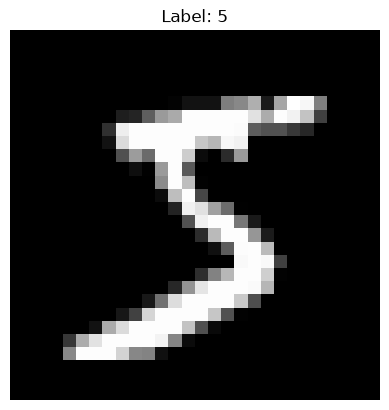

In [11]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

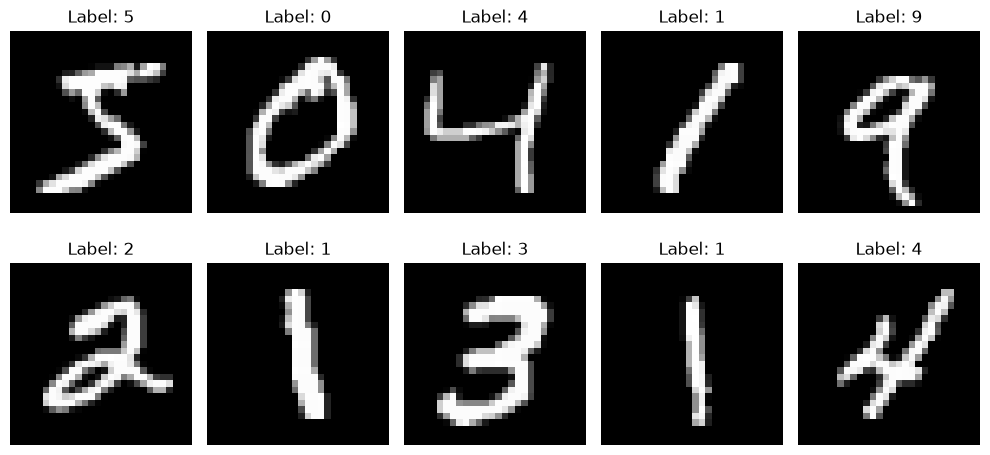

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
image = X_train[0]

print("Shape:", image.shape)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())
print("Unique values:", len(np.unique(image)))

Shape: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 255
Unique values: 85


In [14]:
unique, counts = np.unique(y_train, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count}")

Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


In [15]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)
y_train: (60000,)
y_test: (10000,)


## 2. Preprocessing

Pixel values are converted from `uint8` integers in the range `[0, 255]` to `float32` values in `[0, 1]`.

The images are then flattened from `28 × 28` arrays into vectors of 784 features because the model is a fully connected network rather than a convolutional network.

In [16]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat:", X_test_flat.shape)

X_train_flat: (60000, 784)
X_test_flat: (10000, 784)


In [18]:
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [19]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

## 3. FCNN Architecture

The model uses two hidden layers:

| Layer | Configuration |
|---|---|
| Input | 784 flattened pixels |
| Hidden 1 | 128 neurons + ReLU |
| Hidden 2 | 64 neurons + ReLU |
| Output | 10 logits |

Cross-entropy loss is used for the ten-class classification task, and Adam with a learning rate of `0.001` is used for optimization.

The output layer produces logits directly; no softmax layer is required because `CrossEntropyLoss` applies the appropriate normalization internally.

In [21]:
class MNIST_FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

In [22]:
model = MNIST_FCNN()

print(model)

MNIST_FCNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [23]:
model.fc1.weight.shape

torch.Size([128, 784])

In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## 4. Baseline Training

The FCNN is trained for five epochs on the normal MNIST representation.

The training loss is tracked across epochs, followed by evaluation on the held-out test set. This establishes the baseline performance before examining the learned first-layer weights and testing the pixel permutation.

In [26]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    average_loss = running_loss / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5], Loss: 0.4242
Epoch [2/5], Loss: 0.1781
Epoch [3/5], Loss: 0.1253
Epoch [4/5], Loss: 0.0972
Epoch [5/5], Loss: 0.0781


In [27]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        
        predictions = torch.argmax(outputs, dim=1)
        
        total += y_batch.size(0)
        correct += (predictions == y_batch).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.38%


## 5. First Hidden-Layer Weight Visualization

The first fully connected layer contains 128 neurons, each with 784 learned weights.

Because 784 = 28 × 28, the weights of an individual neuron can be reshaped into a 28×28 grid and visualized as a heatmap.

These visualizations show which input pixels contribute positively or negatively to each neuron's pre-activation. Structured regions indicate that the neuron has learned non-random combinations of input coordinates.

In [28]:
first_layer_weights = model.fc1.weight.detach().cpu().numpy()

print(first_layer_weights.shape)

(128, 784)


In [29]:
selected_weights = first_layer_weights[:10]

print(selected_weights.shape)

(10, 784)


In [30]:
weight_images = selected_weights.reshape(10, 28, 28)

print(weight_images.shape)

(10, 28, 28)


### Note on the Training Runs

The model used for the first-layer weight visualization and the models used in the normal-versus-scrambled comparison are separate training runs.

The visualization is therefore used to inspect representative learned first-layer weights, while the later experiment provides the controlled accuracy comparison.

## 6. Experiment — Fixed Pixel Permutation

To test whether the FCNN depends on the original spatial arrangement of MNIST pixels, a single random permutation of the 784 input coordinates is generated.

The same permutation is applied to every training and test image.

This destroys the visual layout of the digits while preserving a consistent mapping between each original pixel and its new input coordinate. The FCNN therefore still receives the same information, but the spatial neighborhood relationships are no longer represented in their original arrangement.

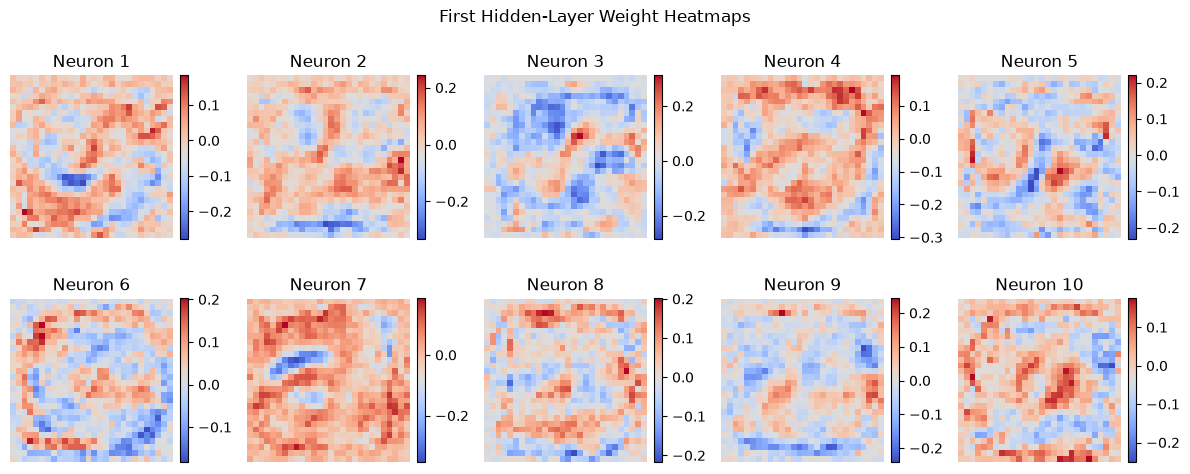

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(weight_images[i], cmap="coolwarm")
    
    ax.set_title(f"Neuron {i + 1}")
    ax.axis("off")
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("First Hidden-Layer Weight Heatmaps")
plt.tight_layout()
plt.show()

### Visualizing the Transformation

The following comparison shows the same image before and after the fixed permutation.

The scrambled image no longer resembles a conventional handwritten digit to a human observer, while its pixel information remains available to the network through the consistently permuted coordinates.

In [32]:
rng = np.random.default_rng(42)

pixel_permutation = rng.permutation(784)

print(pixel_permutation.shape)
print(pixel_permutation[:20])

(784,)
[350 776 554 700 688 544 667 406 707 605 772 237 204 520 136 445  96 218
 649  83]


In [33]:
X_train_scrambled = X_train_flat[:, pixel_permutation]
X_test_scrambled = X_test_flat[:, pixel_permutation]

In [34]:
print("Normal:", X_train_flat.shape)
print("Scrambled:", X_train_scrambled.shape)

Normal: (60000, 784)
Scrambled: (60000, 784)


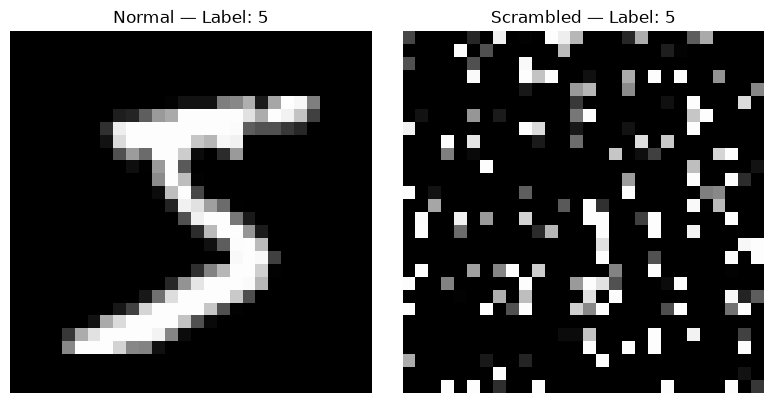

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(X_train_flat[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Normal — Label: {y_train[0]}")
axes[0].axis("off")

axes[1].imshow(X_train_scrambled[0].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Scrambled — Label: {y_train[0]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 7. Normal vs Scrambled MNIST

The scrambled dataset is converted into PyTorch tensors and DataLoaders using the same batch size and training procedure as the normal dataset.

A fresh FCNN is trained separately on the normal data and another fresh FCNN is trained on the scrambled data. Both models use the same architecture, optimizer, learning rate, and five-epoch training budget.

In [37]:
X_train_scrambled_tensor = torch.tensor(
    X_train_scrambled,
    dtype=torch.float32
)

X_test_scrambled_tensor = torch.tensor(
    X_test_scrambled,
    dtype=torch.float32
)

In [38]:
scrambled_train_dataset = TensorDataset(
    X_train_scrambled_tensor,
    y_train_tensor
)

scrambled_test_dataset = TensorDataset(
    X_test_scrambled_tensor,
    y_test_tensor
)

In [39]:
scrambled_train_loader = DataLoader(
    scrambled_train_dataset,
    batch_size=128,
    shuffle=True
)

scrambled_test_loader = DataLoader(
    scrambled_test_dataset,
    batch_size=128,
    shuffle=False
)

### Controlled Comparison

The normal and scrambled models are trained independently from fresh initializations.

The comparison therefore asks whether the fixed rearrangement of input coordinates causes a meaningful loss in classification performance under the same model architecture and training budget.

In [40]:
def train_model(model, train_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {average_loss:.4f}"
        )

In [41]:
def evaluate_model(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)

            predictions = torch.argmax(outputs, dim=1)

            total += y_batch.size(0)
            correct += (predictions == y_batch).sum().item()

    return 100 * correct / total

In [42]:
normal_model = MNIST_FCNN()

train_model(
    normal_model,
    train_loader,
    epochs=5
)

Epoch [1/5], Loss: 0.4202
Epoch [2/5], Loss: 0.1708
Epoch [3/5], Loss: 0.1206
Epoch [4/5], Loss: 0.0901
Epoch [5/5], Loss: 0.0722


In [43]:
normal_accuracy = evaluate_model(
    normal_model,
    test_loader
)

print(f"Normal MNIST accuracy: {normal_accuracy:.2f}%")

Normal MNIST accuracy: 97.27%


In [44]:
scrambled_model = MNIST_FCNN()

train_model(
    scrambled_model,
    scrambled_train_loader,
    epochs=5
)

Epoch [1/5], Loss: 0.4268
Epoch [2/5], Loss: 0.1832
Epoch [3/5], Loss: 0.1221
Epoch [4/5], Loss: 0.0915
Epoch [5/5], Loss: 0.0718


In [45]:
scrambled_accuracy = evaluate_model(
    scrambled_model,
    scrambled_test_loader
)

print(f"Scrambled MNIST accuracy: {scrambled_accuracy:.2f}%")

Scrambled MNIST accuracy: 97.37%


In [46]:
print(f"Normal MNIST:    {normal_accuracy:.2f}%")
print(f"Scrambled MNIST: {scrambled_accuracy:.2f}%")
print(f"Difference:      {normal_accuracy - scrambled_accuracy:.2f} percentage points")

Normal MNIST:    97.27%
Scrambled MNIST: 97.37%
Difference:      -0.10 percentage points


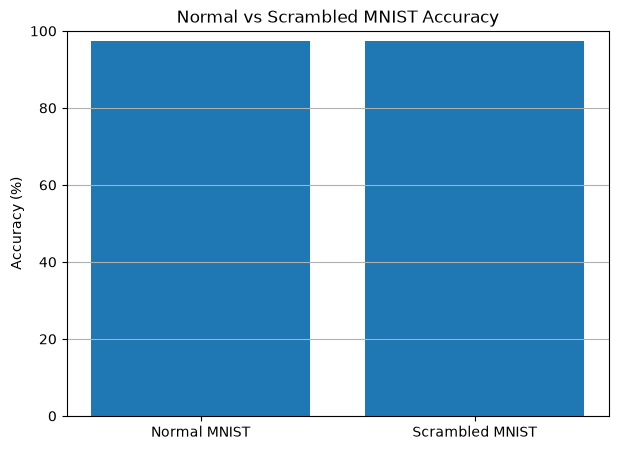

In [47]:
accuracies = [normal_accuracy, scrambled_accuracy]
labels = ["Normal MNIST", "Scrambled MNIST"]

plt.figure(figsize=(7, 5))

plt.bar(labels, accuracies)

plt.ylabel("Accuracy (%)")
plt.title("Normal vs Scrambled MNIST Accuracy")

plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()

## 8. Results and Interpretation

The two models achieve nearly identical test accuracy:

| Dataset | Test Accuracy |
|---|---:|
| Normal MNIST | 97.27% |
| Scrambled MNIST | 97.37% |
| Difference | -0.10 percentage points |

The difference is negligible in this experiment. The scrambled model does not suffer a meaningful accuracy loss despite the destruction of the original visual layout.

### What this demonstrates

A fully connected layer assigns independent learned weights to each input coordinate. It does not inherently encode the assumption that nearby pixels should be treated as spatial neighbors.

Because the same permutation is applied to every image, the network can learn a new mapping from the permuted coordinates to the digit classes.

Therefore, the experiment demonstrates an important distinction:

- **FCNN flexibility:** it can learn useful representations even when input coordinates are consistently rearranged.
- **FCNN limitation:** it has no built-in spatial inductive bias that exploits local relationships between neighboring pixels.

The result does not mean that spatial structure is unimportant for image recognition. Instead, it shows that a standard FCNN can learn the task without having spatial locality built into its architecture.

## 9. Final Takeaway

This experiment shows that a flattened FCNN can achieve high MNIST classification accuracy without relying on the original spatial arrangement of pixels.

The learned first-layer weights contain structured combinations of input coordinates, while the fixed-permutation experiment demonstrates that the network can relearn those coordinate relationships after the pixels are rearranged.

The key architectural insight is that a fully connected network is flexible with respect to input coordinates, but this flexibility comes without an inherent spatial prior. Architectures such as convolutional neural networks explicitly encode locality and weight sharing, whereas the FCNN must learn all coordinate relationships from the data.